# Baseline YOLO26 Rebar Segmentation Visualization

This notebook validates the TWCC baseline summary CSV, compares baseline runs, evaluates the best checkpoint on the DS-B test split with Ultralytics Val mode, and visualizes segmentation masks on DS-B test images.


## Setup


In [2]:
from pathlib import Path
import csv
import math
import os
import re
import tempfile

ROOT = Path.cwd().resolve()
if ROOT.name == "rebar-segementation-yolo26":
    PROJECT_DIR = ROOT
    ROOT = ROOT.parent
else:
    PROJECT_DIR = ROOT / "rebar-segementation-yolo26"

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

try:
    import yaml
except ImportError:
    yaml = None

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass

    def display(obj):
        print(obj)

BASELINE_DIR = PROJECT_DIR / "results" / "baseline_yolo26_twcc"
RUNS_DIR = BASELINE_DIR / "runs" / "segment"
SUMMARY_CSV = BASELINE_DIR / "baseline_metrics_summary.csv"
DS_B_DIR = ROOT / "datasets" / "ds-b-custom-sam3-v1"
DS_B_DATA_YAML = DS_B_DIR / "data.yaml"
DS_B_TEST_IMAGES = DS_B_DIR / "test" / "images"
DS_B_TEST_LABELS = DS_B_DIR / "test" / "labels"
VAL_OUTPUT_DIR = BASELINE_DIR / "val"

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print(f"Repository root: {ROOT}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Baseline summary: {SUMMARY_CSV}")
print(f"DS-B test images: {DS_B_TEST_IMAGES}")


Repository root: /Users/hungkaihsiao/Documents/rebar-works/model-training
Project directory: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26
Baseline summary: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/baseline_metrics_summary.csv
DS-B test images: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/images


In [3]:
def require_path(path, kind="path"):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {kind}: {path}")
    return path


def load_yaml(path):
    if yaml is None:
        raise ImportError("PyYAML is required. Install dependencies from rebar-segementation-yolo26/requirements.txt")
    path = require_path(path, "YAML file")
    with path.open("r") as f:
        return yaml.safe_load(f) or {}


def read_csv_rows(path):
    path = require_path(path, "CSV file")
    with path.open("r", newline="") as f:
        return list(csv.DictReader(f))


def as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def fmt_metric(value):
    value = as_float(value)
    if value is None or math.isnan(value):
        return "nan"
    return f"{value:.6f}"


def infer_run_metadata(run_name):
    match = re.fullmatch(r"yolo26x-baseline-(.+)-aug([01])-v1", run_name)
    if not match:
        raise ValueError(f"Unexpected baseline run name format: {run_name}")
    dataset_mix = "+".join(part.upper() for part in match.group(1).split("-"))
    augmentation_mode = f"aug{match.group(2)}"
    return dataset_mix, augmentation_mode


def display_table(rows):
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        display(rows)


def image_paths(directory):
    directory = require_path(directory, "image directory")
    return sorted(path for path in directory.iterdir() if path.suffix.lower() in IMAGE_SUFFIXES)


## Validate Baseline Summary CSV


In [4]:
def compute_run_summary(run_dir):
    run_dir = Path(run_dir)
    results_csv = require_path(run_dir / "results.csv", "run results.csv")
    rows = read_csv_rows(results_csv)
    if not rows:
        raise ValueError(f"No rows found in {results_csv}")

    best_row = max(
        rows,
        key=lambda row: as_float(row.get("metrics/mAP50-95(M)"))
        if as_float(row.get("metrics/mAP50-95(M)")) is not None
        else -math.inf,
    )
    final_row = rows[-1]
    dataset_mix, augmentation_mode = infer_run_metadata(run_dir.name)

    return {
        "run name": run_dir.name,
        "dataset mix": dataset_mix,
        "augmentation mode": augmentation_mode,
        "best epoch": str(int(float(best_row["epoch"]))),
        "best mask mAP50-95": fmt_metric(best_row.get("metrics/mAP50-95(M)")),
        "best mask mAP50": fmt_metric(best_row.get("metrics/mAP50(M)")),
        "final mask mAP50-95": fmt_metric(final_row.get("metrics/mAP50-95(M)")),
        "results path": str(results_csv),
        "_sort_score": as_float(best_row.get("metrics/mAP50-95(M)")),
    }


def compute_all_run_summaries():
    require_path(RUNS_DIR, "baseline runs directory")
    rows = [compute_run_summary(path) for path in sorted(RUNS_DIR.iterdir()) if path.is_dir()]
    rows.sort(key=lambda row: row["_sort_score"] if row["_sort_score"] is not None else -math.inf, reverse=True)
    for rank, row in enumerate(rows, start=1):
        row["rank"] = str(rank)
    return rows


def validate_summary_csv(summary_rows, computed_rows):
    keys = [
        "rank",
        "run name",
        "dataset mix",
        "augmentation mode",
        "best epoch",
        "best mask mAP50-95",
        "best mask mAP50",
        "final mask mAP50-95",
    ]
    summary_by_run = {row["run name"]: row for row in summary_rows}
    computed_by_run = {row["run name"]: row for row in computed_rows}
    issues = []

    for run_name, computed in computed_by_run.items():
        summary = summary_by_run.get(run_name)
        if summary is None:
            issues.append({"run name": run_name, "field": "row", "summary": "missing", "computed": "present"})
            continue
        for key in keys:
            if str(summary.get(key)) != str(computed.get(key)):
                issues.append({
                    "run name": run_name,
                    "field": key,
                    "summary": summary.get(key),
                    "computed": computed.get(key),
                })

    for run_name in sorted(set(summary_by_run) - set(computed_by_run)):
        issues.append({"run name": run_name, "field": "row", "summary": "present", "computed": "missing"})

    return issues

summary_rows = read_csv_rows(SUMMARY_CSV)
computed_rows = compute_all_run_summaries()
validation_issues = validate_summary_csv(summary_rows, computed_rows)

print(f"Summary CSV rows: {len(summary_rows)}")
print(f"Computed run rows: {len(computed_rows)}")
print(f"Discrepancies: {len(validation_issues)}")

if validation_issues:
    display(Markdown("**Baseline summary CSV has discrepancies.**"))
    display_table(validation_issues)
    raise AssertionError("baseline_metrics_summary.csv does not accurately reflect local run results")

assert len(summary_rows) == 14, f"Expected 14 summary rows, found {len(summary_rows)}"
display(Markdown("**Baseline summary CSV is accurate: 14 rows checked, 0 discrepancies.**"))


Summary CSV rows: 14
Computed run rows: 14
Discrepancies: 0


**Baseline summary CSV is accurate: 14 rows checked, 0 discrepancies.**

## Baseline Metrics Summary


In [5]:
if pd is None:
    baseline_df = summary_rows
    display_table(summary_rows)
else:
    baseline_df = pd.DataFrame(summary_rows).copy()
    numeric_cols = ["rank", "best epoch", "best mask mAP50-95", "best mask mAP50", "final mask mAP50-95"]
    for col in numeric_cols:
        baseline_df[col] = pd.to_numeric(baseline_df[col])
    baseline_df = baseline_df.sort_values("rank")
    display(baseline_df)


,rank,run name,dataset mix,augmentation mode,best epoch,best mask mAP50-95,best mask mAP50,final mask mAP50-95,results path
0,1,yolo26x-baseline-a-aug1-v1,A,aug1,47,0.48919,0.78216,0.48797,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
1,2,yolo26x-baseline-a-aug0-v1,A,aug0,49,0.48390,0.76433,0.48270,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
2,3,yolo26x-baseline-a-c-aug1-v1,A+C,aug1,48,0.46117,0.75338,0.45829,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
3,4,yolo26x-baseline-a-c-aug0-v1,A+C,aug0,38,0.43406,0.69282,0.43247,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
4,5,yolo26x-baseline-a-b-aug1-v1,A+B,aug1,50,0.42939,0.70120,0.42939,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
5,6,yolo26x-baseline-a-b-c-aug1-v1,A+B+C,aug1,49,0.40970,0.67578,0.40957,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
6,7,yolo26x-baseline-a-b-aug0-v1,A+B,aug0,49,0.40433,0.65935,0.40380,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
7,8,yolo26x-baseline-a-b-c-aug0-v1,A+B+C,aug0,50,0.37440,0.61359,0.37440,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
8,9,yolo26x-baseline-c-aug1-v1,C,aug1,47,0.33033,0.54360,0.32800,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...
9,10,yolo26x-baseline-c-aug0-v1,C,aug0,49,0.22009,0.39474,0.22009,/tmp/rebar-baseline-yolo26/runs/segment/yolo26...


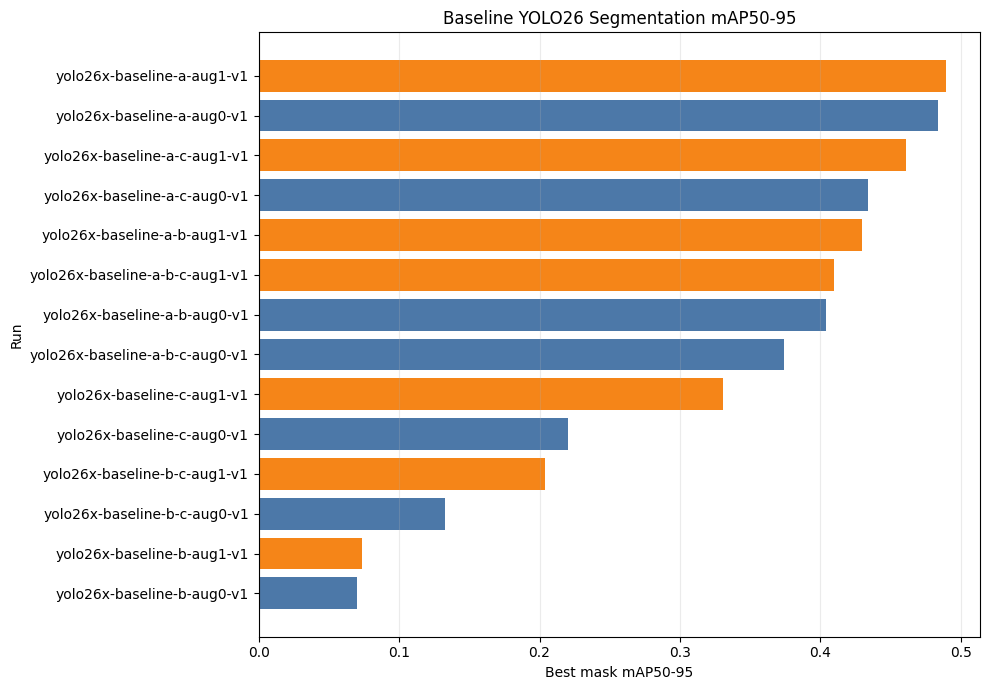

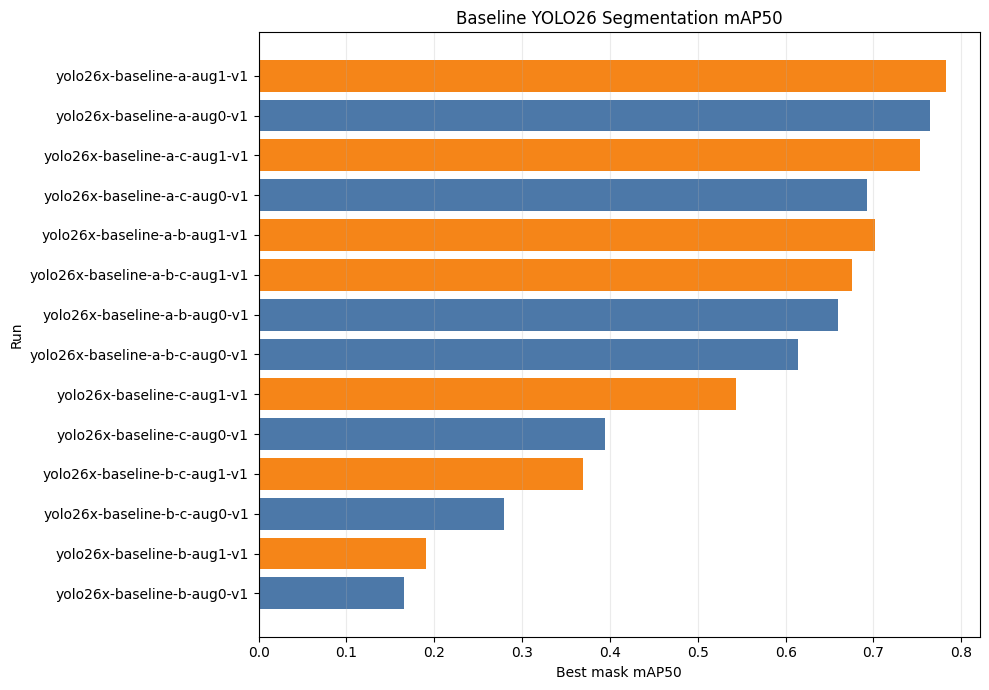

In [6]:
if pd is None:
    raise ImportError("pandas is required for the summary plots. Install pandas or view the table above.")

plot_df = baseline_df.sort_values("best mask mAP50-95", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors = plot_df["augmentation mode"].map({"aug0": "#4C78A8", "aug1": "#F58518"}).fillna("#767676")
ax.barh(plot_df["run name"], plot_df["best mask mAP50-95"], color=colors)
ax.set_xlabel("Best mask mAP50-95")
ax.set_ylabel("Run")
ax.set_title("Baseline YOLO26 Segmentation mAP50-95")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["run name"], plot_df["best mask mAP50"], color=colors)
ax.set_xlabel("Best mask mAP50")
ax.set_ylabel("Run")
ax.set_title("Baseline YOLO26 Segmentation mAP50")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
display(fig)
plt.close(fig)


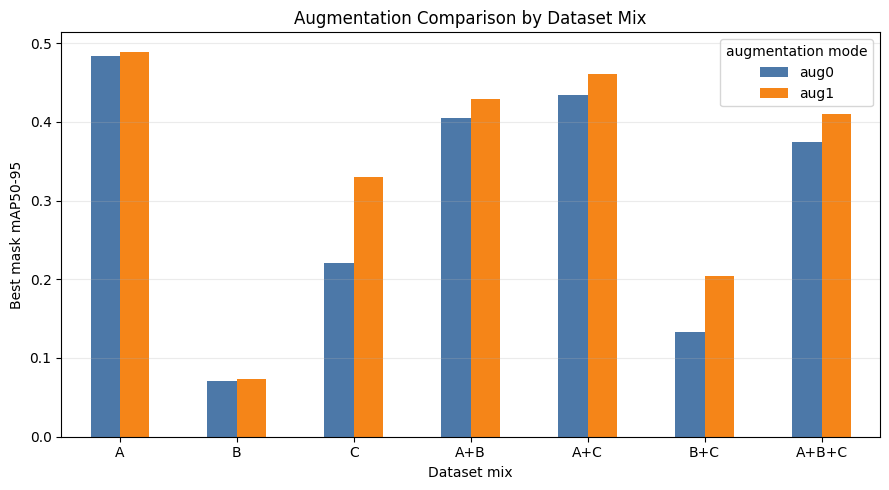

In [7]:
if pd is None:
    raise ImportError("pandas is required for grouped summary plots.")

pivot = baseline_df.pivot(index="dataset mix", columns="augmentation mode", values="best mask mAP50-95")
pivot = pivot.reindex(sorted(pivot.index, key=lambda value: (len(value), value)))
ax = pivot.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#F58518"])
ax.set_xlabel("Dataset mix")
ax.set_ylabel("Best mask mAP50-95")
ax.set_title("Augmentation Comparison by Dataset Mix")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
display(ax.figure)
plt.close(ax.figure)


## Select Best Model


In [8]:
best_row = min(summary_rows, key=lambda row: int(row["rank"]))
best_run_name = "yolo26x-baseline-a-b-aug1-v1"
best_run_dir = RUNS_DIR / best_run_name
best_model_path = best_run_dir / "weights" / "best.pt"
best_results_image = best_run_dir / "results.png"
best_results_csv = best_run_dir / "results.csv"

require_path(best_run_dir, "best run directory")
require_path(best_model_path, "best checkpoint")
require_path(best_results_image, "best run results image")
require_path(best_results_csv, "best run results.csv")

best_summary = {
    "rank": best_row["rank"],
    "run name": best_run_name,
    "dataset mix": best_row["dataset mix"],
    "augmentation mode": best_row["augmentation mode"],
    "best epoch": best_row["best epoch"],
    "best mask mAP50-95": best_row["best mask mAP50-95"],
    "best mask mAP50": best_row["best mask mAP50"],
    "checkpoint": str(best_model_path.relative_to(ROOT)),
}
display_table([best_summary])


,rank,run name,dataset mix,augmentation mode,best epoch,best mask mAP50-95,best mask mAP50,checkpoint
0,1,yolo26x-baseline-a-b-aug1-v1,A,aug1,47,0.489190,0.782160,rebar-segementation-yolo26/results/baseline_yo...


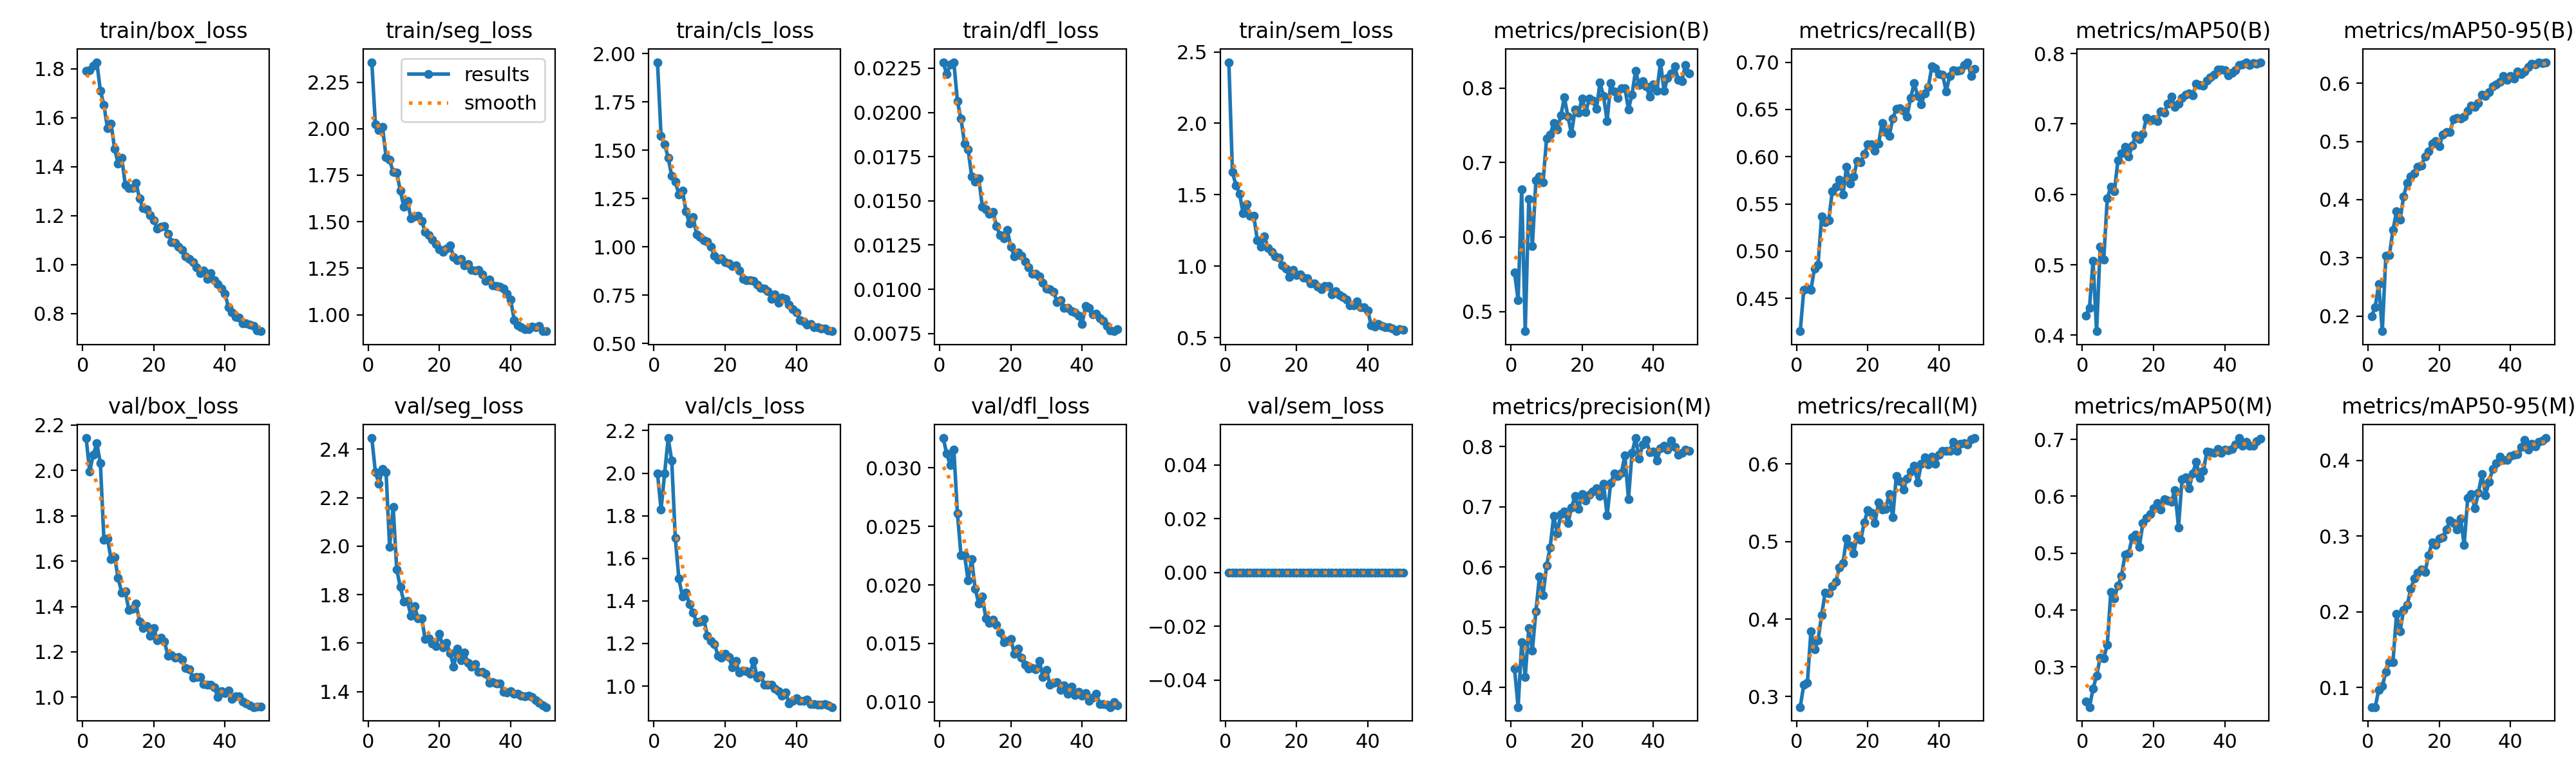

In [9]:
display(Image.open(best_results_image))


## Validate Best Model on DS-B Test Split

Ultralytics Val mode defaults to the validation split, so this notebook explicitly passes `split="test"` and checks the DS-B test image directory before evaluation.


In [10]:
def resolve_dataset_split_dir(data_yaml_path, split):
    data_yaml_path = Path(data_yaml_path)
    data = load_yaml(data_yaml_path)
    if split not in data:
        raise KeyError(f"{data_yaml_path} does not define a '{split}' split")

    split_value = data[split]
    if isinstance(split_value, (list, tuple)):
        raise ValueError(f"Expected a single path for split '{split}', got {split_value}")

    candidate = Path(split_value)
    candidates = []
    if candidate.is_absolute():
        candidates.append(candidate)
    else:
        yaml_parent = data_yaml_path.parent
        dataset_root = Path(data.get("path", yaml_parent))
        if not dataset_root.is_absolute():
            dataset_root = (yaml_parent / dataset_root).resolve()

        candidates.extend([
            (dataset_root / candidate).resolve(),
            (yaml_parent / candidate).resolve(),
            (dataset_root / split / "images").resolve(),
            (yaml_parent / split / "images").resolve(),
        ])

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not resolve split '{split}' from {data_yaml_path}. Tried: "
        + ", ".join(str(path) for path in candidates)
    )

require_path(DS_B_DATA_YAML, "DS-B data.yaml")
require_path(DS_B_TEST_LABELS, "DS-B test labels directory")
resolved_test_images = resolve_dataset_split_dir(DS_B_DATA_YAML, "test")
expected_test_images = DS_B_TEST_IMAGES.resolve()

if resolved_test_images != expected_test_images:
    raise AssertionError(
        f"Resolved test split does not match expected DS-B test images. "
        f"resolved={resolved_test_images}, expected={expected_test_images}"
    )

test_images = image_paths(resolved_test_images)
if not test_images:
    raise FileNotFoundError(f"No test images found in {resolved_test_images}")

print(f"DS-B data.yaml: {DS_B_DATA_YAML}")
print(f"Resolved test split: {resolved_test_images}")
print(f"Test image count: {len(test_images)}")
print(f"Test label count: {len(list(DS_B_TEST_LABELS.glob('*.txt')))}")


DS-B data.yaml: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/data.yaml
Resolved test split: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/images
Test image count: 15
Test label count: 15


In [11]:
def write_test_only_data_yaml(source_yaml, output_yaml):
    data = load_yaml(source_yaml)
    output_yaml = Path(output_yaml)
    output_yaml.parent.mkdir(parents=True, exist_ok=True)

    test_only_data = dict(data)
    test_only_data["path"] = str(DS_B_DIR.resolve())
    test_only_data["train"] = "train/images"
    test_only_data["val"] = "valid/images"
    test_only_data["test"] = "test/images"

    with output_yaml.open("w") as f:
        yaml.safe_dump(test_only_data, f, sort_keys=False)
    return output_yaml

# Roboflow exports can contain paths like '../test/images'. Write a notebook-local
# validation YAML with explicit paths so Val mode evaluates DS-B test/images.
TEST_VAL_DATA_YAML = write_test_only_data_yaml(DS_B_DATA_YAML, VAL_OUTPUT_DIR / "ds_b_test_val_data.yaml")
print(f"Validation data YAML: {TEST_VAL_DATA_YAML}")
print(TEST_VAL_DATA_YAML.read_text())


Validation data YAML: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/val/ds_b_test_val_data.yaml
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- rebar
roboflow:
  workspace: hungkais-workspace
  project: test_dahanxi-mhbq7
  version: 12
  license: CC BY 4.0
  url: https://universe.roboflow.com/hungkais-workspace/test_dahanxi-mhbq7/dataset/12
path: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1



In [12]:
try:
    from ultralytics import YOLO
except ImportError as exc:
    raise ImportError(
        "Ultralytics is required for validation. Install dependencies with: "
        "python -m pip install -r rebar-segementation-yolo26/requirements.txt"
    ) from exc

model = YOLO(str(best_model_path))
test_metrics = model.val(
    data=str(TEST_VAL_DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    workers=0,
    plots=True,
    project=str(VAL_OUTPUT_DIR),
    name="best_on_ds_b_test",
    exist_ok=True,
)

metric_rows = [
    {"metric": "seg.map", "value": test_metrics.seg.map},
    {"metric": "seg.map50", "value": test_metrics.seg.map50},
    {"metric": "seg.map75", "value": test_metrics.seg.map75},
    {"metric": "box.map", "value": test_metrics.box.map},
    {"metric": "box.map50", "value": test_metrics.box.map50},
    {"metric": "box.map75", "value": test_metrics.box.map75},
]
display_table(metric_rows)
print(f"Val mode output directory: {VAL_OUTPUT_DIR / 'best_on_ds_b_test'}")


Ultralytics 8.4.48 🚀 Python-3.10.20 torch-2.11.0 CPU (Apple M1)
YOLO26x-seg summary (fused): 207 layers, 62,727,887 parameters, 0 gradients, 313.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.1 ms, read: 445.2±85.4 MB/s, size: 111.2 KB)
val: Scanning /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 898.8Kit/s 0.0s
val: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/images/20250620_101942_jpg.rf.c8863492aeca5d6966363c8a2e452b79.jpg: 3 duplicate labels removed
val: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/images/20250620_102446_jpg.rf.48171368c2da37439246ffa59fffaa97.jpg: 2 duplicate labels removed
val: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1/test/images/20250620_113200_jpg.rf.b46165dee42174f74f85acb336d602a8.jpg: 9 duplicate labels 

,metric,value
0,seg.map,0.095168
1,seg.map50,0.230080
2,seg.map75,0.079487
3,box.map,0.207133
4,box.map50,0.335462
5,box.map75,0.220397


Val mode output directory: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/val/best_on_ds_b_test


## DS-B Test Segmentation Overlays


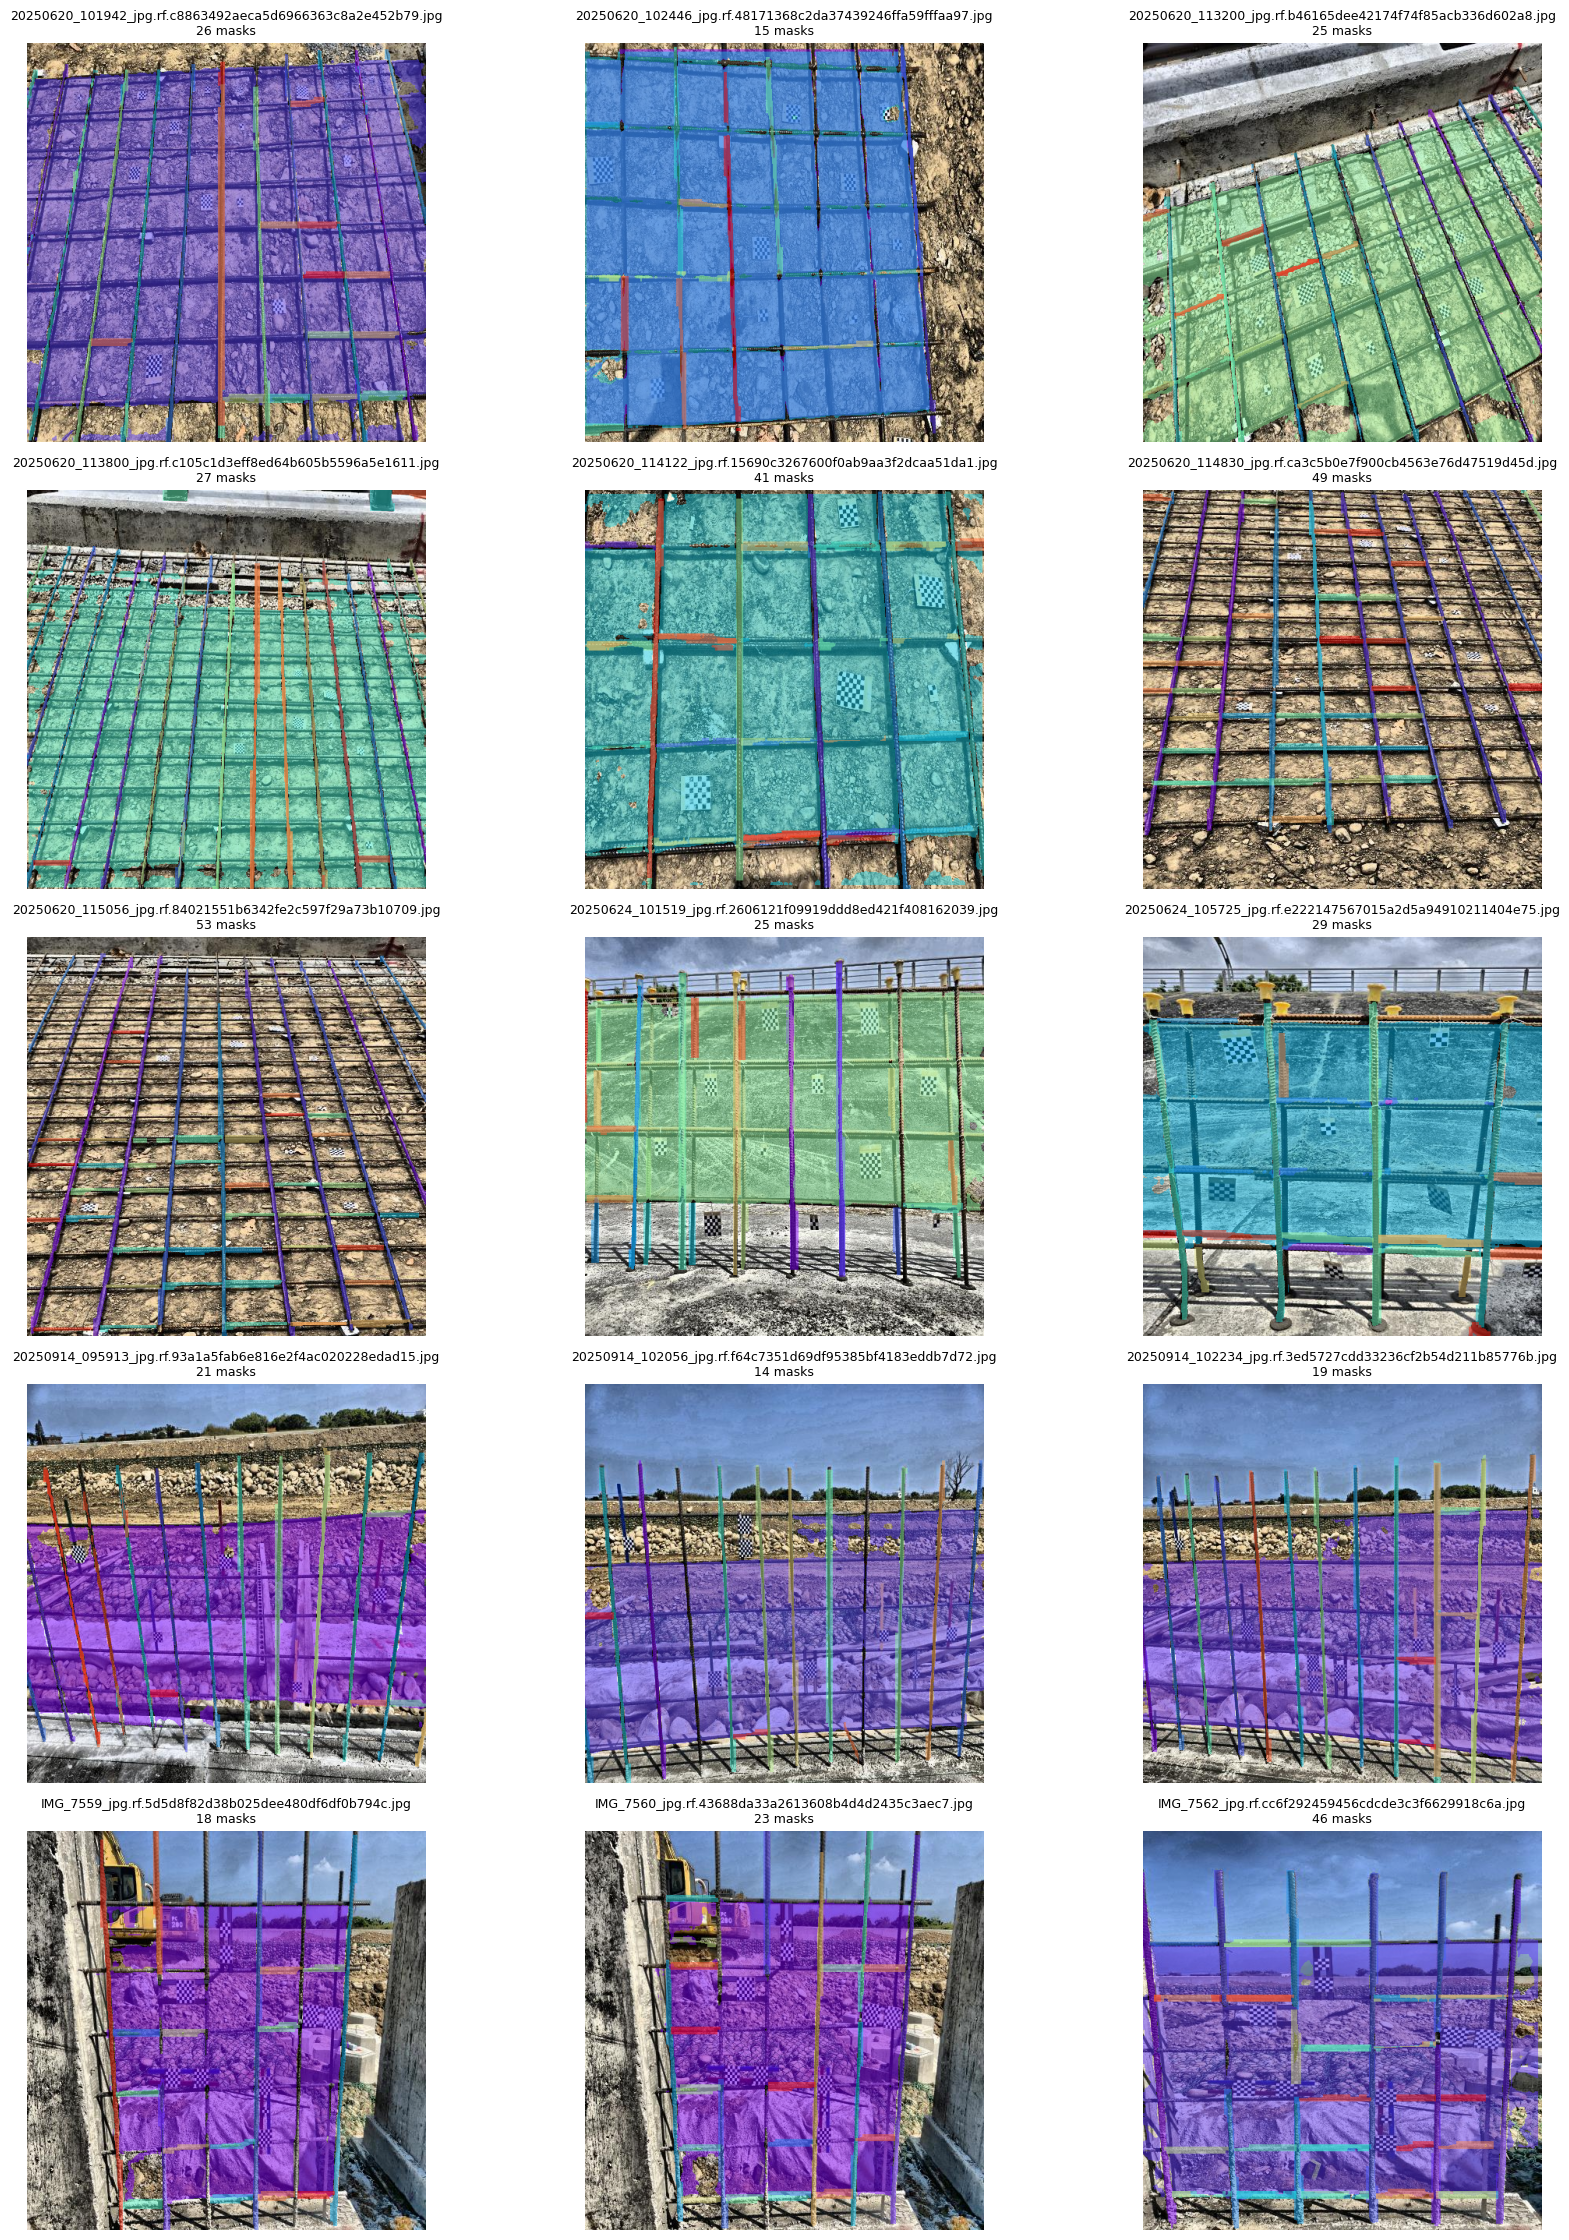

In [13]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    if masks is None or len(masks) == 0:
        return image

    masks = 255 * masks.cpu().numpy().astype(np.uint8)
    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [tuple(int(channel * 255) for channel in cmap(index)[:3]) for index in range(n_masks)]

    for mask, color in zip(masks, colors):
        mask_image = Image.fromarray(mask)
        if mask_image.size != image.size:
            mask_image = mask_image.resize(image.size, Image.Resampling.NEAREST)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask_image.point(lambda value: int(value * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


def display_test_mask_overlays(model_path, source_images, conf=0.25, max_images=15, cols=3):
    from ultralytics import YOLO

    source_images = Path(source_images).resolve()
    if source_images != DS_B_TEST_IMAGES.resolve():
        raise AssertionError(f"Overlay source must be DS-B test/images, got {source_images}")

    paths = image_paths(source_images)[:max_images]
    if not paths:
        raise FileNotFoundError(f"No test images found in {source_images}")

    model = YOLO(str(model_path))
    predictions = model.predict(source=[str(path) for path in paths], conf=conf, save=False, verbose=False)

    rows = int(np.ceil(len(predictions) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4.5))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, result, image_path in zip(axes.ravel(), predictions, paths):
        image = Image.open(image_path)
        masks = result.masks.data if result.masks is not None else None
        overlay = overlay_masks(image, masks)
        mask_count = 0 if masks is None else len(masks)
        ax.imshow(overlay)
        ax.set_title(f"{image_path.name}\n{mask_count} masks", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    display(fig)
    plt.close(fig)

display_test_mask_overlays(best_model_path, DS_B_TEST_IMAGES, conf=0.25, max_images=15, cols=3)
